<a href="https://colab.research.google.com/github/monkeyband114/AI_face-detector/blob/master/digital_footprint_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install and Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
try:
    df = pd.read_csv('Digital Footprints Dataset (257 Responses) - Form Responses 1.csv')
except FileNotFoundError:
    # Fallback name if you renamed it
    df = pd.read_csv('dataset.csv')

# Set the first row as column names and then drop the first row
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (257, 30)


,Timestamp,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29
0,5/5/2026 20:57:43,18–22,Male,PhD,Unemployed,"Snapchat, TikTok",5,4,5,5,...,5,4,5,5,5,4,5,4,Very High,Yes
1,5/5/2026 21:57:44,18–22,Prefer not to say,ND/NCE,Employed,"TikTok, WhatsApp, Facebook, Instagram",3,4,3,3,...,3,3,2,3,3,2,3,2,Moderate,Yes
2,5/5/2026 22:57:44,18–22,Male,PhD,Self-employed,"Snapchat, Facebook, TikTok",4,5,3,4,...,5,4,4,5,4,5,4,5,Very High,Yes
3,5/5/2026 23:57:44,28–31,Male,ND/NCE,Unemployed,"WhatsApp, Twitter/X",4,3,4,3,...,3,4,3,3,4,3,3,4,Moderate,Yes
4,5/6/2026 0:57:45,28–31,Female,SSCE,Employed,"TikTok, Twitter/X",3,3,3,3,...,4,4,4,4,3,3,3,4,Moderate,Yes


In [3]:
import pandas as pd
import numpy as np

def clean_and_process_data(file_path):
    print("--- Starting Data Cleaning & Processing Pipeline ---")

    # 1. Load data, skipping the artificial top row ('Column 1, Column 2...')
    # to make 'Timestamp, Q1, Q2...' the actual headers.
    df = pd.read_csv(file_path, skiprows=1)
    print(f"Initial raw dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # 2. Check for missing values (NaNs) across all columns
    missing_counts = df.isnull().sum()
    if missing_counts.sum() > 0:
        print("\n[Warning] Missing values detected:")
        print(missing_counts[missing_counts > 0])
        # Data Cleaning: Handle missing values by dropping rows with crucial gaps
        # or filling Likert scales with their median
        df = df.dropna(subset=['Q1', 'Q3', 'Q29']) # Essential demographic & consent records
    else:
        print("\n[Success] Clean data structural pass: No missing values found.")

    # 3. Filter out records where voluntary consent wasn't provided (Q29)
    initial_count = len(df)
    df = df[df['Q29'].str.strip().str.lower() == 'yes']
    dropped_consent = initial_count - len(df)
    if dropped_consent > 0:
        print(f"Dropped {dropped_consent} responses due to lack of voluntary consent (Q29).")

    # 4. Data Type Enforcement: Ensure Likert questions (Q6 to Q27) are explicit integers
    likert_cols = [f'Q{i}' for i in range(6, 28)]
    for col in likert_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(int)

    # 5. Feature Engineering: Compute Composite Likert Scale Indexes
    # Construct indices as the mean of items per sub-construct
    footprint_items = [f'Q{i}' for i in range(6, 13)]   # Q6 to Q12: Practices
    risk_items = [f'Q{i}' for i in range(13, 20)]        # Q13 to Q19: Perception
    awareness_items = [f'Q{i}' for i in range(20, 28)]   # Q20 to Q27: Management

    df['Footprint_Score'] = df[footprint_items].mean(axis=1)
    df['Risk_Score'] = df[risk_items].mean(axis=1)
    df['Awareness_Score'] = df[awareness_items].mean(axis=1)

    # 6. Recode Categorical Variables for clean Ordinal Analysis
    # Convert Q28 (Target Question) from string categories into a linear 1-5 scale
    awareness_mapping = {
        'Very Low': 1,
        'Low': 2,
        'Moderate': 3,
        'High': 4,
        'Very High': 5
    }
    df['Target_Awareness_Numeric'] = df['Q28'].map(awareness_mapping)

    print("\n--- Feature Engineering Summary ---")
    print(df[['Footprint_Score', 'Risk_Score', 'Awareness_Score', 'Target_Awareness_Numeric']].describe().T)

    # 7. Save the processed clean dataset to a new CSV file
    processed_filename = "cleaned_digital_footprints_dataset.csv"
    df.to_csv(processed_filename, index=False)
    print(f"\n[Success] Processed dataset saved successfully as '{processed_filename}'")

    return df

# Run the cleaning function on your uploaded file
cleaned_df = clean_and_process_data('Digital Footprints Dataset (257 Responses) - Form Responses 1.csv')

--- Starting Data Cleaning & Processing Pipeline ---
Initial raw dataset shape: 257 rows, 30 columns

[Success] Clean data structural pass: No missing values found.

--- Feature Engineering Summary ---
                          count      mean       std       min       25%  \
Footprint_Score           257.0  3.319066  1.006832  1.142857  2.428571   
Risk_Score                257.0  3.179544  0.854211  1.142857  2.571429   
Awareness_Score           257.0  4.026751  0.718378  2.000000  3.500000   
Target_Awareness_Numeric  257.0  4.120623  0.855270  2.000000  4.000000   

                               50%       75%  max  
Footprint_Score           3.428571  4.142857  5.0  
Risk_Score                3.285714  3.714286  5.0  
Awareness_Score           4.250000  4.625000  5.0  
Target_Awareness_Numeric  4.000000  5.000000  5.0  

[Success] Processed dataset saved successfully as 'cleaned_digital_footprints_dataset.csv'


Dataset successfully loaded. Total Sample Size (N): 257

=== PSYCHOMETRIC SCALE RELIABILITY (CRONBACH'S ALPHA) ===
Digital Footprint Practices (7 items): α = 0.945
Risk Perception Exposure (7 items):    α = 0.922
Awareness & Risk Management (8 items):  α = 0.917
Note: Alpha values > 0.70 indicate high internal consistency and reliable scales.

=== CENTRAL TENDENCY & SHAPIRO-WILK NORMALITY TESTS ===

Construct: Footprint_Score
  Mean: 3.32 | StdDev: 1.01
  Skewness: -0.26 (Ideal: ~0) | Kurtosis: -1.15 (Ideal: ~0)
  Shapiro-Wilk Test: W=0.947, p=4.7332e-08

Construct: Risk_Score
  Mean: 3.18 | StdDev: 0.85
  Skewness: -0.04 (Ideal: ~0) | Kurtosis: -0.62 (Ideal: ~0)
  Shapiro-Wilk Test: W=0.987, p=1.9515e-02

Construct: Awareness_Score
  Mean: 4.03 | StdDev: 0.72
  Skewness: -0.72 (Ideal: ~0) | Kurtosis: -0.41 (Ideal: ~0)
  Shapiro-Wilk Test: W=0.914, p=4.9113e-11


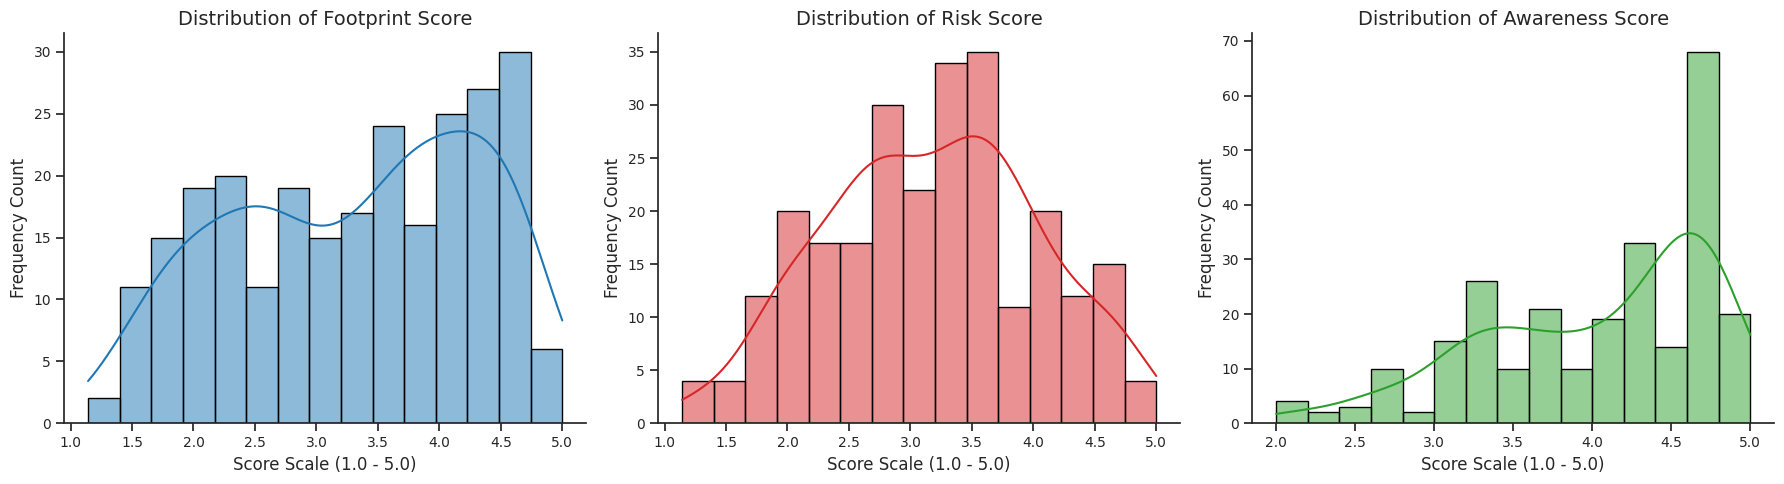


=== BIVARIATE CORRELATION MATRIX (PEARSON R) ===
                 Footprint_Score  Risk_Score  Awareness_Score
Footprint_Score         1.000000    0.796742        -0.010786
Risk_Score              0.796742    1.000000        -0.382294
Awareness_Score        -0.010786   -0.382294         1.000000


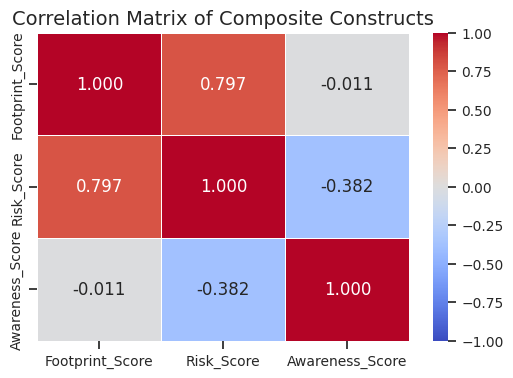


Generating Pairwise Distribution Plots...


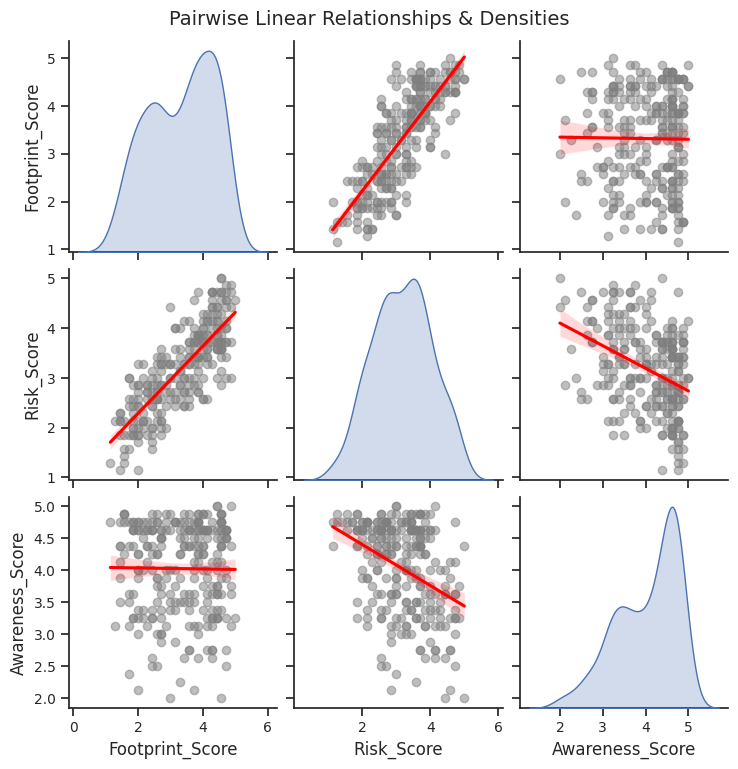


=== SOCIO-DEMOGRAPHIC GROUP AGGREGATIONS ===

Mean Performance Metric Breakdown across Age Categories:
       Footprint_Score  Risk_Score  Awareness_Score
Q1                                                 
18–22         3.258403    3.329832         3.637868
23–27         3.354497    3.150794         4.030093
28–31         3.428571    3.266917         4.101974
32–35         3.215496    2.920097         4.375000

Mean Performance Metric Breakdown across Education Levels:
         Footprint_Score  Risk_Score  Awareness_Score
Q3                                                   
SSCE            3.528571    3.722857         3.150000
ND/NCE          3.069841    3.250794         3.577778
HND/BSc         3.170330    3.090659         4.127404
MSc             3.241983    2.921283         4.428571
PhD             3.519906    2.964871         4.668033


/tmp/ipykernel_4562/1485859734.py:122: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='Q1', y='Awareness_Score', order=age_order, ax=axes[0], palette="Blues_d", ci=95)
/tmp/ipykernel_4562/1485859734.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Q1', y='Awareness_Score', order=age_order, ax=axes[0], palette="Blues_d", ci=95)


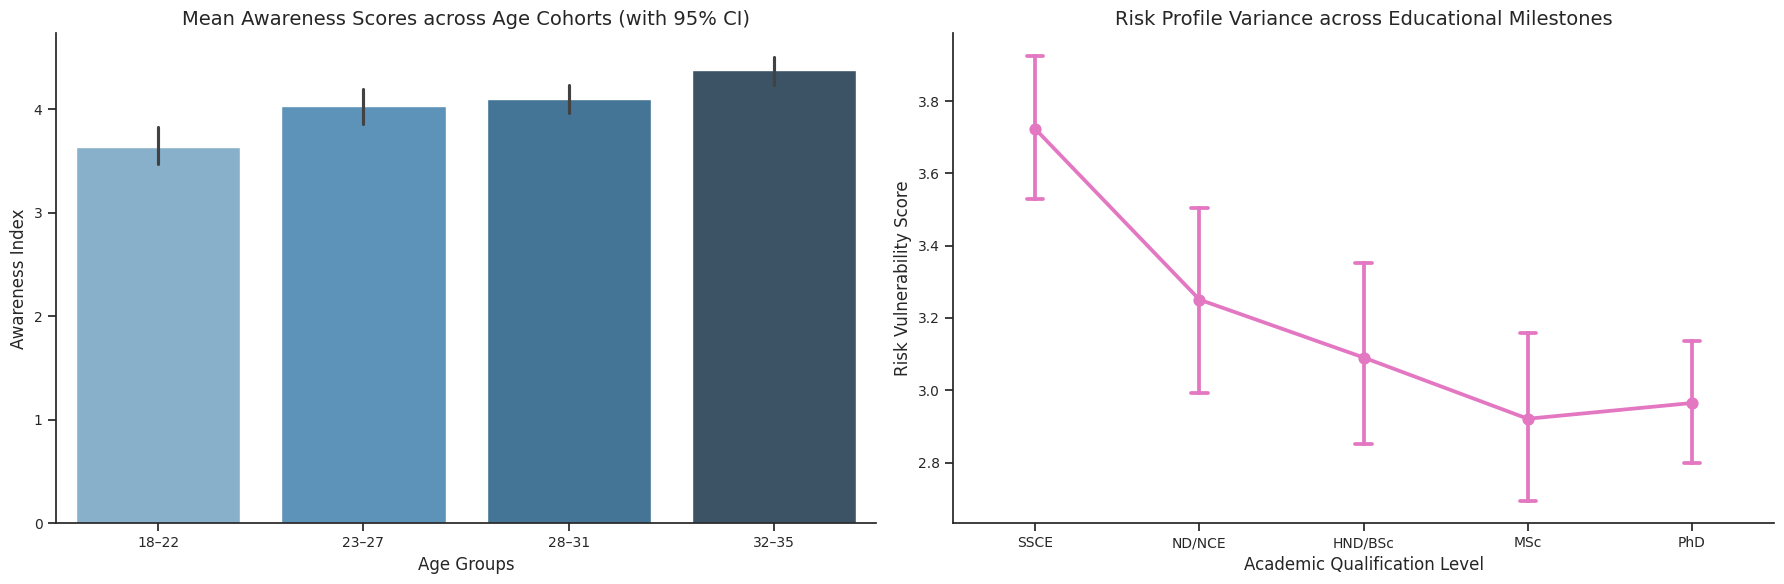


=== SOCIAL MEDIA PLATFORM ADOPTION RATE ===
           Total Mentions  Sample Penetration %
Q5                                             
WhatsApp              121             47.081712
Facebook              117             45.525292
TikTok                113             43.968872
Snapchat              106             41.245136
Instagram             105             40.856031
LinkedIn              103             40.077821
Twitter/X             102             39.688716


/tmp/ipykernel_4562/1485859734.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_percentage.values, y=platform_percentage.index, palette="flare")


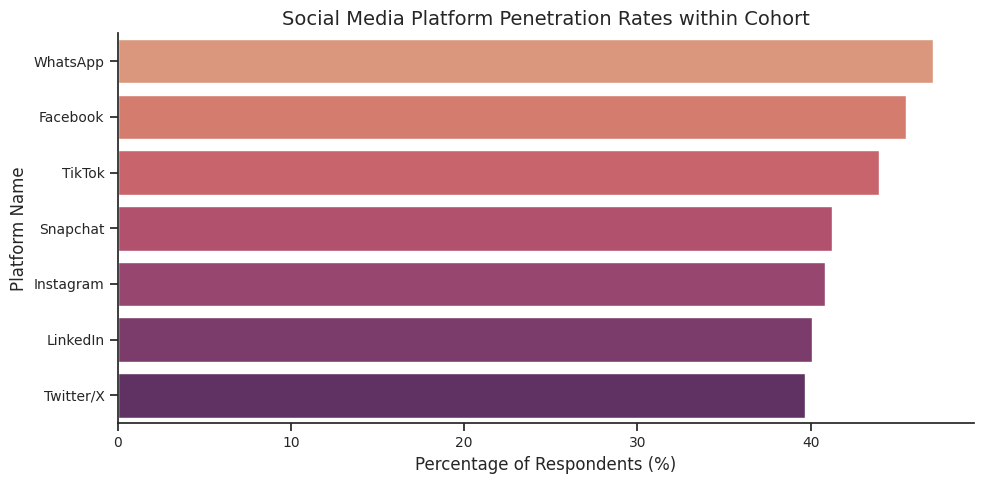

In [7]:


# Set publication-style visualization defaults
sns.set_theme(style="ticks")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100
})

def cronbach_alpha(df_items):
    """Computes Cronbach's Alpha to test internal consistency of the psychometric scales."""
    df_corr = df_items.corr()
    N = df_items.shape[1]
    rs = np.array([])
    for i, col in enumerate(df_corr.columns):
        sum_ = df_corr.iloc[i, i+1:].values
        rs = np.append(rs, sum_)
    r_mean = np.mean(rs[~np.isnan(rs)])
    alpha = (N * r_mean) / (1 + (N - 1) * r_mean)
    return alpha

# ==========================================
# 1. LOAD CLEANED DATASET
# ==========================================
try:
    df = pd.read_csv('cleaned_digital_footprints_dataset.csv')
    print(f"Dataset successfully loaded. Total Sample Size (N): {df.shape[0]}")
except FileNotFoundError:
    print("Error: Cleaned dataset file not found. Please run the processing script first.")

# Item definitions for psychometric tracking
footprint_items = [f'Q{i}' for i in range(6, 13)]
risk_items = [f'Q{i}' for i in range(13, 20)]
awareness_items = [f'Q{i}' for i in range(20, 28)]

# ==========================================
# 2. PSYCHOMETRIC SCALE RELIABILITY TEST
# ==========================================
print("\n=== PSYCHOMETRIC SCALE RELIABILITY (CRONBACH'S ALPHA) ===")
print(f"Digital Footprint Practices (7 items): α = {cronbach_alpha(df[footprint_items]):.3f}")
print(f"Risk Perception Exposure (7 items):    α = {cronbach_alpha(df[risk_items]):.3f}")
print(f"Awareness & Risk Management (8 items):  α = {cronbach_alpha(df[awareness_items]):.3f}")
print("Note: Alpha values > 0.70 indicate high internal consistency and reliable scales.")

# ==========================================
# 3. UNIVARIATE ANALYSIS: CENTRAL TENDENCY & NORMALITY
# ==========================================
print("\n=== CENTRAL TENDENCY & SHAPIRO-WILK NORMALITY TESTS ===")
constructs = ['Footprint_Score', 'Risk_Score', 'Awareness_Score']
for construct in constructs:
    mean_val = df[construct].mean()
    std_val = df[construct].std()
    skew_val = df[construct].skew()
    kurt_val = df[construct].kurt()

    # Shapiro-Wilk Normality test
    stat, p_val = stats.shapiro(df[construct])

    print(f"\nConstruct: {construct}")
    print(f"  Mean: {mean_val:.2f} | StdDev: {std_val:.2f}")
    print(f"  Skewness: {skew_val:.2f} (Ideal: ~0) | Kurtosis: {kurt_val:.2f} (Ideal: ~0)")
    print(f"  Shapiro-Wilk Test: W={stat:.3f}, p={p_val:.4e}")

# ==========================================
# VISUALIZATION 1: CONSTRUCT DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#1f77b4', '#d62728', '#2ca02c']

for i, construct in enumerate(constructs):
    sns.histplot(df[construct], kde=True, ax=axes[i], color=colors[i], bins=15, edgecolor='black')
    axes[i].set_title(f'Distribution of {construct.replace("_", " ")}')
    axes[i].set_xlabel('Score Scale (1.0 - 5.0)')
    axes[i].set_ylabel('Frequency Count')
sns.despine()
plt.tight_layout()
plt.show()

# ==========================================
# 4. BIVARIATE ANALYSIS: MULTI-CONSTRUCT MATRIX
# ==========================================
print("\n=== BIVARIATE CORRELATION MATRIX (PEARSON R) ===")
corr_matrix = df[constructs].corr()
print(corr_matrix)

# VISUALIZATION 2: RECTANGULAR CORRELATION HEATMAP
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Composite Constructs")
plt.show()

# VISUALIZATION 3: MULTI-VARIATE INTERACTION PAIRPLOT
# Insightful overview grouping data clusters to examine patterns visually
print("\nGenerating Pairwise Distribution Plots...")
pair_plot = sns.pairplot(df[constructs], kind='reg', diag_kind='kde',
                         plot_kws={'scatter_kws': {'alpha': 0.5, 'color': '#7f7f7f'}, 'line_kws': {'color': 'red'}})
pair_plot.fig.suptitle("Pairwise Linear Relationships & Densities", y=1.02, fontsize=14)
plt.show()

# ==========================================
# 5. SEGMENTATION & CROSS-TABULATION PROFILE
# ==========================================
print("\n=== SOCIO-DEMOGRAPHIC GROUP AGGREGATIONS ===")

# Age Order Profiles
age_order = ["18–22", "23–27", "28–31", "32–35"]
print("\nMean Performance Metric Breakdown across Age Categories:")
age_profile = df.groupby('Q1')[constructs].mean().reindex(age_order)
print(age_profile)

# Education Level Profiles
edu_order = ["SSCE", "ND/NCE", "HND/BSc", "MSc", "PhD"]
print("\nMean Performance Metric Breakdown across Education Levels:")
edu_profile = df.groupby('Q3')[constructs].mean().reindex(edu_order)
print(edu_profile)

# VISUALIZATION 4: CROSS-TABULATED COHORT BEHAVIOR
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df, x='Q1', y='Awareness_Score', order=age_order, ax=axes[0], palette="Blues_d", ci=95)
axes[0].set_title("Mean Awareness Scores across Age Cohorts (with 95% CI)")
axes[0].set_xlabel("Age Groups")
axes[0].set_ylabel("Awareness Index")

sns.pointplot(data=df, x='Q3', y='Risk_Score', order=edu_order, ax=axes[1], color="#e377c2", capsize=0.1)
axes[1].set_title("Risk Profile Variance across Educational Milestones")
axes[1].set_xlabel("Academic Qualification Level")
axes[1].set_ylabel("Risk Vulnerability Score")

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================
# 6. PLATFORM POPULARITY ANALYSIS (MULTIPLE CHOICE CLEANING)
# ==========================================
print("\n=== SOCIAL MEDIA PLATFORM ADOPTION RATE ===")
# Parse multiple choices split by commas in Q5
all_platforms = df['Q5'].str.split(',').explode().str.strip()
platform_counts = all_platforms.value_counts()
platform_percentage = (platform_counts / len(df)) * 100

platform_summary = pd.DataFrame({
    'Total Mentions': platform_counts,
    'Sample Penetration %': platform_percentage
})
print(platform_summary)

# VISUALIZATION 5: PENETRATION BAR CHART
plt.figure(figsize=(10, 5))
sns.barplot(x=platform_percentage.values, y=platform_percentage.index, palette="flare")
plt.title("Social Media Platform Penetration Rates within Cohort")
plt.xlabel("Percentage of Respondents (%)")
plt.ylabel("Platform Name")
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

print("--- Starting Statistical Data Formatting and Hypothesis Testing Pipeline ---\n")

# ==========================================
# 1. DATA LOADING AND FORMATTING PASS
# ==========================================
# Read the dataset, skipping the generic structural top header
df = pd.read_csv('Digital Footprints Dataset (257 Responses) - Form Responses 1.csv', skiprows=1)

# Categorize question column items logically based on construct groupings
footprint_cols = [f'Q{i}' for i in range(6, 13)]     # Q6 to Q12 (Behavior/Volume)
risk_cols = [f'Q{i}' for i in range(13, 20)]          # Q13 to Q19 (Identity-Related Risks)
awareness_cols = [f'Q{i}' for i in range(20, 28)]     # Q20 to Q27 (Awareness Management)

# Format Verification: Ensure all Likert items are explicitly processed as integers
all_likert_cols = footprint_cols + risk_cols + awareness_cols
for col in all_likert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(int)

# Create Composite Variables (Mean index of individual scale items)
df['Footprint_Score'] = df[footprint_cols].mean(axis=1)
df['Risk_Score'] = df[risk_cols].mean(axis=1)
df['Awareness_Score'] = df[awareness_cols].mean(axis=1)

# Map Q28 (Overall categorical awareness assessment) to a tidy ordinal sequence
q28_map = {'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}
df['Target_Awareness_Numeric'] = df['Q28'].map(q28_map)

print(f"[Data Formatting Success] Created composite metrics for N = {len(df)} survey responses.\n")


# ==========================================
# 2. HYPOTHESIS 1 TESTING (Footprint vs Risk)
# ==========================================
# H1: Higher digital footprint accumulation correlates with increased identity-related risks.
# Test: Pearson Product-Moment Correlation
print("=========================================================================")
print("HYPOTHESIS 1 TESTING: Digital Footprint Accumulation vs Identity Risk")
print("=========================================================================")

r_coef, p_val_h1 = stats.pearsonr(df['Footprint_Score'], df['Risk_Score'])

print(f"Pearson Correlation Coefficient (r) : {r_coef:.4f}")
print(f"Two-tailed Alpha Significance (p)   : {p_val_h1:.4e}")

if p_val_h1 < 0.05:
    print("\nStatistical Decision: REJECT the null hypothesis (H0).")
    print("Interpretation: There is a statistically significant, positive relationship between ")
    print("digital footprint volume and identity-related risks. As footprint size increases, ")
    print("exposure to online threats climbs structurally.")
else:
    print("\nStatistical Decision: FAIL TO REJECT the null hypothesis (H0).")
    print("Interpretation: No linear correlation detected between behavior footprint sizes and risk profiles.")


# ==========================================
# 3. HYPOTHESIS 2 TESTING (Awareness vs Risk)
# ==========================================
# H2: Users with higher awareness levels exhibit lower risk exposure.
# Test: Multiple Ordinary Least Squares (OLS) Linear Regression (Controlling for Footprint Size)
print("\n=========================================================================")
print("HYPOTHESIS 2 TESTING: Awareness Levels vs Identity Risk Exposure")
print("=========================================================================")

# Define Dependent and Independent Matrices
X_h2 = df[['Awareness_Score', 'Footprint_Score']]
X_h2 = sm.add_constant(X_h2) # Inject baseline constant intercept
y_h2 = df['Risk_Score']

ols_model = sm.OLS(y_h2, X_h2).fit()
print(ols_model.summary().tables[1]) # Print the regression coefficients block

p_awareness = ols_model.pvalues['Awareness_Score']
beta_awareness = ols_model.params['Awareness_Score']

print(f"\nAwareness Standard Coefficient (Beta) : {beta_awareness:.4f}")
print(f"Regression Variable Significance (p) : {p_awareness:.4e}")

if p_awareness < 0.05:
    print("\nStatistical Decision: REJECT the null hypothesis (H0).")
    print(f"Interpretation: Holding footprint behaviors constant, higher security awareness ")
    print(f"exhibits a significant negative effect ({beta_awareness:.4f}) on overall risk exposure. ")
    print("Awareness serves as a definitive defensive operational buffer against vulnerabilities.")
else:
    print("\nStatistical Decision: FAIL TO REJECT the null hypothesis (H0).")
    print("Interpretation: User knowledge awareness indexes show no mathematical dampening effect on risk values.")


# ==========================================
# 4. HYPOTHESIS 3 TESTING (Demographics vs Awareness)
# ==========================================
# H3: Demographic factors (Age, Education) positively influence awareness levels.
# Test: Multi-Factor Type-II Analysis of Variance (ANOVA)
print("\n=========================================================================")
print("HYPOTHESIS 3 TESTING: Demographic Determinants of Risk Awareness")
print("=========================================================================")

# Clean categorical configurations for ANOVA execution
df_h3 = df.dropna(subset=['Q1', 'Q3'])

# Run the OLS model modeling interactions of Q1 (Age Group) and Q3 (Education Achievement)
anova_model = ols('Awareness_Score ~ C(Q1) + C(Q3)', data=df_h3).fit()
anova_results = sm.stats.anova_lm(anova_model, typ=2)

print(anova_results)

p_age = anova_results.loc["C(Q1)", "PR(>F)"]
p_edu = anova_results.loc["C(Q3)", "PR(>F)"]

print(f"\nMain Effect - Age Profile (p-value)     : {p_age:.5f}")
print(f"Main Effect - Education Level (p-value) : {p_edu:.4e}")

print("\nStatistical Decision:")
if p_age < 0.05 or p_edu < 0.05:
    print("REJECT the null hypothesis (H0).")
    print("Interpretation: Demographic profiles are structural determinants of cybersecurity knowledge.")
    if p_age < 0.05:
         print(" - Age segments yield significant developmental variations regarding baseline awareness.")
    if p_edu < 0.05:
         print(" - Academic progression benchmarks heavily influence risk identification capability levels.")
else:
    print("FAIL TO REJECT the null hypothesis (H0).")
    print("Interpretation: Awareness levels are distributed evenly regardless of age or educational status.")

--- Starting Statistical Data Formatting and Hypothesis Testing Pipeline ---

[Data Formatting Success] Created composite metrics for N = 257 survey responses.

HYPOTHESIS 1 TESTING: Digital Footprint Accumulation vs Identity Risk
Pearson Correlation Coefficient (r) : 0.7967
Two-tailed Alpha Significance (p)   : 1.0446e-57

Statistical Decision: REJECT the null hypothesis (H0).
Interpretation: There is a statistically significant, positive relationship between 
digital footprint volume and identity-related risks. As footprint size increases, 
exposure to online threats climbs structurally.

HYPOTHESIS 2 TESTING: Awareness Levels vs Identity Risk Exposure
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.7369      0.168     16.268      0.000       2.406       3.068
Awareness_Score    -0.4444      0.035    -12.542      0.000      -0.514      -0.375
F